### Importing Libraries 

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

Matplotlib is building the font cache; this may take a moment.


### Connecting to My Azure Database 

In [2]:
username = "AdminKamal"
password = "Ghana9061$"

host = "kaml-edu-analytics-mysql.mysql.database.azure.com"
database = "educational_analytics"

engine = create_engine(

    f"mysql+pymysql://{username}:{password}@{host}/{database}"

)

### Loading the table views created in MySQL database  

In [3]:
performance = pd.read_sql(
    "SELECT * FROM vw_student_performance",
    engine
)

attendance = pd.read_sql(
    "SELECT * FROM vw_attendance_summary",
    engine
)

### inspection of the data 

In [4]:
performance.head()

,Student_ID,Student_Name,Term_ID,Term_Name,English,Mathematics,Integrated_Science,Computing,Career_Technology,Creative_Arts,French,Ghanaian_Language,Religious_Moral_Education,Social_Studies,Overall_Average
0,ST0059,SALIFU ZULAIHA,1,Term 1,55.5,41.5,42.5,54.0,34.5,48.5,61.0,36.5,59.0,49.5,48.25
1,ST0058,HABLEAME SHILLA,1,Term 1,56.0,38.5,57.0,71.0,57.5,52.0,72.0,53.5,60.5,71.5,58.95
2,ST0055,WORMENOR JULIA,1,Term 1,75.0,44.5,77.0,76.5,70.0,61.5,87.5,73.5,66.5,81.5,71.35
3,ST0054,TWUMASI VERA,1,Term 1,69.0,66.5,74.5,61.0,58.5,58.0,73.0,68.0,72.0,77.5,67.80
4,ST0053,TETTEH MAVIS,1,Term 1,61.5,45.5,59.5,61.5,49.5,54.0,75.5,49.0,65.0,62.5,58.35


In [5]:
attendance.head()

,Student_ID,Student_Name,Term_ID,Term_Name,Attendance,Attendance_Category
0,ST0001,AGBENOR ALFRED,1,Term 1,69,High
1,ST0002,AGBENU JORDAN,1,Term 1,63,High
2,ST0003,AGBO PRINCE,1,Term 1,55,High
3,ST0004,AGBOTSE EBENEZER,1,Term 1,69,High
4,ST0005,APPIAH EMMANUEL,1,Term 1,54,Moderate


In [6]:
performance.info

<bound method DataFrame.info of     Student_ID       Student_Name  Term_ID Term_Name  English  Mathematics  \
0       ST0059     SALIFU ZULAIHA        1    Term 1     55.5         41.5   
1       ST0058    HABLEAME SHILLA        1    Term 1     56.0         38.5   
2       ST0055   WORMENOR JULIA          1    Term 1     75.0         44.5   
3       ST0054     TWUMASI VERA          1    Term 1     69.0         66.5   
4       ST0053     TETTEH MAVIS          1    Term 1     61.5         45.5   
..         ...                ...      ...       ...      ...          ...   
153     ST0005   APPIAH EMMANUEL         3    Term 3     49.5         19.5   
154     ST0004  AGBOTSE EBENEZER         3    Term 3     49.5         28.5   
155     ST0003        AGBO PRINCE        3    Term 3     56.5         50.0   
156     ST0002     AGBENU JORDAN         3    Term 3     55.5         31.0   
157     ST0001   AGBENOR  ALFRED         3    Term 3     74.0         38.0   

     Integrated_Science  Comput

In [7]:
attendance.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Student_ID           168 non-null    str  
 1   Student_Name         168 non-null    str  
 2   Term_ID              168 non-null    int64
 3   Term_Name            168 non-null    str  
 4   Attendance           168 non-null    int64
 5   Attendance_Category  168 non-null    str  
dtypes: int64(2), str(4)
memory usage: 8.0 KB


### Data Quality Assessment 

In [9]:
performance.shape

(158, 15)

In [10]:
attendance.shape

(168, 6)

In [11]:
performance.isnull().sum()

Student_ID                   0
Student_Name                 0
Term_ID                      0
Term_Name                    0
English                      0
Mathematics                  0
Integrated_Science           0
Computing                    0
Career_Technology            0
Creative_Arts                0
French                       0
Ghanaian_Language            0
Religious_Moral_Education    0
Social_Studies               0
Overall_Average              0
dtype: int64

In [13]:
attendance.isnull().sum()

Student_ID             0
Student_Name           0
Term_ID                0
Term_Name              0
Attendance             0
Attendance_Category    0
dtype: int64

In [14]:
performance.duplicated().sum()

np.int64(0)

In [15]:
attendance.duplicated().sum()

np.int64(0)

In [16]:
performance.describe()

,Term_ID,English,Mathematics,Integrated_Science,Computing,Career_Technology,Creative_Arts,French,Ghanaian_Language,Religious_Moral_Education,Social_Studies,Overall_Average
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.00000
mean,1.993671,55.686709,42.373418,52.547468,46.876582,49.218354,53.098101,49.322785,44.832278,59.455696,56.838608,51.02500
std,0.817771,8.446249,14.254727,9.002085,11.387736,11.945395,8.140185,13.093013,12.861661,11.980927,11.083825,8.16625
min,1.000000,36.500000,12.500000,36.000000,15.000000,22.500000,37.000000,18.500000,18.500000,23.000000,30.000000,34.60000
25%,1.000000,50.000000,32.125000,46.500000,39.000000,41.625000,47.500000,39.750000,35.500000,53.000000,49.750000,46.20000
50%,2.000000,54.500000,42.250000,51.750000,47.500000,48.000000,53.000000,48.000000,43.750000,60.000000,57.750000,50.82500
75%,3.000000,60.000000,51.875000,57.500000,54.875000,56.500000,57.500000,58.000000,53.500000,67.500000,63.375000,55.47500
max,3.000000,81.000000,86.500000,88.500000,76.500000,84.000000,84.000000,87.500000,75.000000,85.500000,81.500000,73.50000


In [17]:
attendance.describe()

,Term_ID,Attendance
count,168.000000,168.000000
mean,1.970238,59.583333
std,0.814727,7.956029
min,1.000000,33.000000
25%,1.000000,54.000000
50%,2.000000,62.000000
75%,3.000000,67.000000
max,3.000000,69.000000


## EXPLORATORY DATA ANALYSIS

### Descriptive Statistics
We begin by generating summary statistics for both the student performance and attendance datasets. These statistics provide an overview of the data distribution, including measures such as the mean, standard deviation, minimum, maximum, and quartiles. This helps us understand the overall characteristics of the dataset before performing more detailed analyses.

In [18]:
performance.describe().T

,count,mean,std,min,25%,50%,75%,max
Term_ID,158.0,1.993671,0.817771,1.0,1.000,2.000,3.000,3.0
English,158.0,55.686709,8.446249,36.5,50.000,54.500,60.000,81.0
Mathematics,158.0,42.373418,14.254727,12.5,32.125,42.250,51.875,86.5
Integrated_Science,158.0,52.547468,9.002085,36.0,46.500,51.750,57.500,88.5
Computing,158.0,46.876582,11.387736,15.0,39.000,47.500,54.875,76.5
Career_Technology,158.0,49.218354,11.945395,22.5,41.625,48.000,56.500,84.0
Creative_Arts,158.0,53.098101,8.140185,37.0,47.500,53.000,57.500,84.0
French,158.0,49.322785,13.093013,18.5,39.750,48.000,58.000,87.5
Ghanaian_Language,158.0,44.832278,12.861661,18.5,35.500,43.750,53.500,75.0
Religious_Moral_Education,158.0,59.455696,11.980927,23.0,53.000,60.000,67.500,85.5


In [19]:
attendance.describe().T

,count,mean,std,min,25%,50%,75%,max
Term_ID,168.0,1.970238,0.814727,1.0,1.0,2.0,3.0,3.0
Attendance,168.0,59.583333,7.956029,33.0,54.0,62.0,67.0,69.0


### Interpretation

The descriptive statistics provide an overview of students' academic performance and attendance across the three academic terms.

The average overall academic score is **51.03%**, indicating that, on average, students achieved just above the minimum passing level. Student performance ranges from **34.6%** to **73.5%**, suggesting noticeable variation in academic achievement across the cohort.

Among the core subjects, **Social Studies (56.84%)**, **English (55.69%)**, and **Integrated Science (52.55%)** recorded the highest average scores, while **Ghanaian Language (44.83%)** and **French (49.32%)** had comparatively lower average performance.

Attendance statistics show an average attendance of **59.58** out of a maximum of **69**, indicating generally good student attendance throughout the academic year. The relatively small standard deviation suggests that attendance levels were fairly consistent among students.

## Distribution of Overall Academic Performance

A histogram is used to visualize the distribution of students' overall academic averages. This helps determine whether performance is concentrated around specific score ranges, identify any skewness in the distribution, and detect potential outliers.

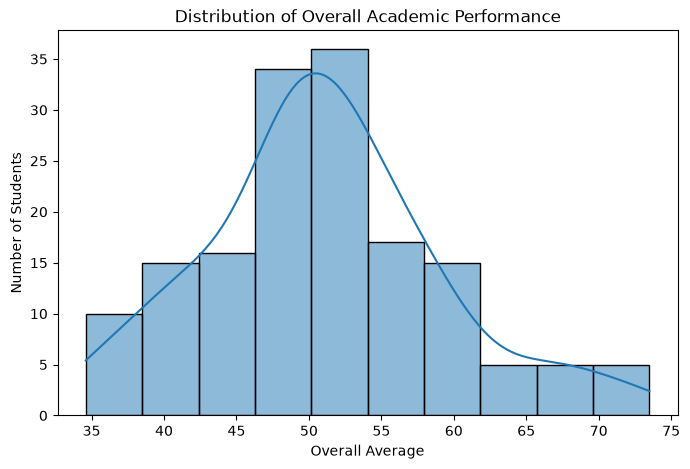

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=performance,
    x="Overall_Average",
    bins=10,
    kde=True
)

plt.title("Distribution of Overall Academic Performance")
plt.xlabel("Overall Average")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
### Interpretation

The histogram shows that students' overall academic performance is concentrated around the **45% to 55%** range, with the highest frequency occurring near **50%**. This indicates that the majority of students achieved average academic performance during the academic year.

Only a small number of students scored above **65%**, while relatively few students obtained scores below **40%**. The distribution is approximately bell-shaped with a slight positive skew, suggesting that exceptionally high-performing students are less common than students with average performance.

Overall, the results indicate that most students are performing at a moderate level, highlighting opportunities for targeted interventions to improve academic achievement and increase the proportion of high-performing students.